In [1]:
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

### Load data

In [2]:
cwd = Path('.')
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir.csv'
data: pd.DataFrame = pd.read_csv(data_path)
data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)

C:\Users\victor\AppData\Local\Temp\ipykernel_2664\376905083.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


### Duplicating data and removing surplus rows

The data consists of rows of match statistics for specific players. 

Since each match has 2 teams of 5 players, you would expect 10 rows for each match. It turns out that there are 12 rows for each match because there are 2 extra rows that contain information about the team as a whole, rather than the players. 

Since we want to analyze the players, we take the teamwide information contained in these 2 rows (which is simply missing information in the player rows) and duplicate it to the player rows of those teams in the places that the players are missing data (if present in the team data). 

In [3]:
for matchid in tqdm(data["gameid"].unique()):
    game = data[data["gameid"] == matchid]
    teams = game["teamid"].unique()

    for teamid in teams:
        team = game[game["teamid"] == teamid]

        players = team[team["position"] != "team"]
        team_stats = team[team["position"] == "team"]

        # fill missing values in players with team stats if available
        for column in data.columns:
            if players[column].isnull().any():
                data.loc[players.index, column] = team_stats[column].item()

  0%|          | 0/1105 [00:00<?, ?it/s]

We then drop all rows that only contain teamwide statistics, as we are interested only in the player performances

In [4]:
data = data.drop(data[data["position"] == "team"].index) 

### Clean data for missing data and unrelated columns

Currently the data is full of missing values as can be seen on the missing value plot below, so we remove the the columns that have many missing values and then the rows that have many missing values. 

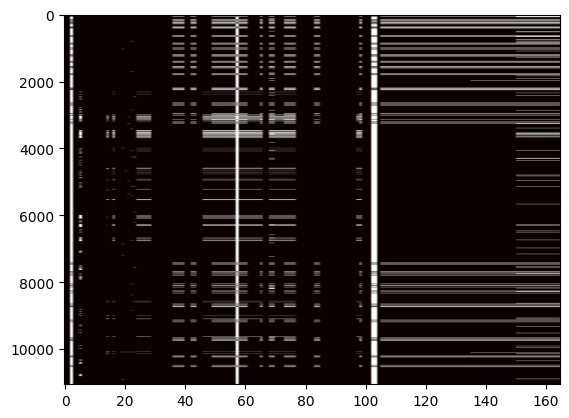

In [5]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

In [6]:
data = data[data["datacompleteness"] == "complete"]
data = data.drop(columns=["datacompleteness", "url", "league", "year", "split", "playoffs", "date", "game", "patch", "participantid", "position", "playername", "playerid", "teamname", "teamid"])

# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.05
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0.05
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

The remaining data no longer contains a large amount of missing data as can be seen on the graph below, and still has 

In [7]:
100 * len(data) / data_len

84.52488687782805

% of the data rows

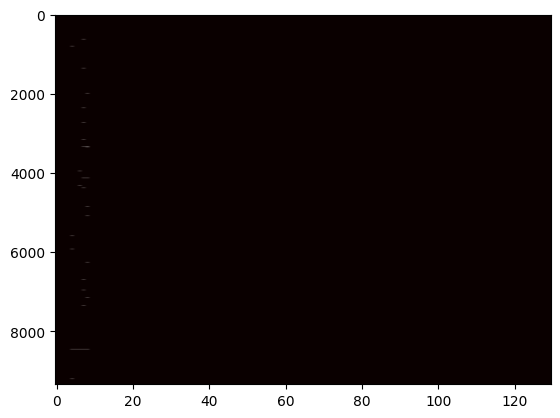

In [8]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()